In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/home/caspian/miniconda3/envs/mmkg/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
with open("outputs/2026-06-22/18-09-56/training_log.json", "r") as f:
    training_logs = json.load(f)["epoch_logs"]
training_logs

{'1': {'timestamp': '2026-06-22T18:11:39.686826',
  'current_learning_rate': 0.0004,
  'training': {'loss': 20.688327598393325,
   'reg': 1.4707363520525014,
   'time_seconds': 96.44537043571472,
   'memory_reserved_mb': 8528.0,
   'memory_allocated_mb': 199.67138671875},
  'validation': {'metrics': {'MRR': 0.09806246310472488,
    'Hit@1': 0.08150140196084976,
    'Hit@3': 0.10477080941200256,
    'Hit@10': 0.12324602156877518},
   'time_seconds': 1.3561420440673828,
   'memory_reserved_mb': 8528.0,
   'memory_allocated_mb': 214.31982421875}},
 '2': {'timestamp': '2026-06-22T18:13:12.795832',
  'current_learning_rate': 0.0003999755732313688,
  'training': {'loss': 19.037843927253125,
   'reg': 1.3834393960053508,
   'time_seconds': 90.03813123703003,
   'memory_reserved_mb': 8528.0,
   'memory_allocated_mb': 203.287109375},
  'validation': {'metrics': {'MRR': 0.10953080654144287,
    'Hit@1': 0.08886810392141342,
    'Hit@3': 0.11587932705879211,
    'Hit@10': 0.1412535011768341},
   

In [3]:
[(epoch, log) for epoch, log in training_logs.items()][0]

('1',
 {'timestamp': '2026-06-22T18:11:39.686826',
  'current_learning_rate': 0.0004,
  'training': {'loss': 20.688327598393325,
   'reg': 1.4707363520525014,
   'time_seconds': 96.44537043571472,
   'memory_reserved_mb': 8528.0,
   'memory_allocated_mb': 199.67138671875},
  'validation': {'metrics': {'MRR': 0.09806246310472488,
    'Hit@1': 0.08150140196084976,
    'Hit@3': 0.10477080941200256,
    'Hit@10': 0.12324602156877518},
   'time_seconds': 1.3561420440673828,
   'memory_reserved_mb': 8528.0,
   'memory_allocated_mb': 214.31982421875}})

In [4]:
training_metrics = {}
for epoch, log in training_logs.items():
    # 安全地获取 training 和 validation 字典，如果不存在则返回空字典 {}
    train_data = log.get("training", {})
    val_data = log.get("validation", {}).get("metrics", {})
    
    training_metrics[epoch] = {
        "loss": train_data.get("loss", None),
        "Val MRR": val_data.get("MRR", None),
        "Val Hit@1": val_data.get("Hit@1", None),
        "Val Hit@3": val_data.get("Hit@3", None),
        "Val Hit@10": val_data.get("Hit@10", None),
    }

training_metrics = pd.DataFrame.from_dict(training_metrics, orient="index")
training_metrics
# pd.DataFrame.from_dict(training_loss, orient="index").plot()

,loss,Val MRR,Val Hit@1,Val Hit@3,Val Hit@10
1,20.688328,0.098062,0.081501,0.104771,0.123246
2,19.037844,0.109531,0.088868,0.115879,0.141254
3,18.521188,0.115218,0.092376,0.120206,0.152596
4,18.086107,0.115996,0.092493,0.121375,0.153648
5,17.713873,0.117807,0.092844,0.125000,0.158209
...,...,...,...,...,...
779,10.842549,0.190505,0.134471,0.224860,0.292563
780,10.840770,0.185430,0.130730,0.216674,0.293732
781,10.839675,0.186489,0.132484,0.216207,0.294200
782,10.853574,0.187894,0.134004,0.219364,0.294317


<Axes: title={'center': 'Loss'}>

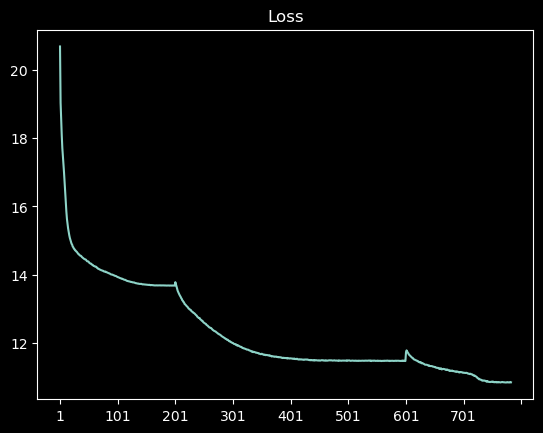

In [5]:
training_metrics["loss"].plot(title="Loss")

<Axes: title={'center': 'Validation Hit@10'}>

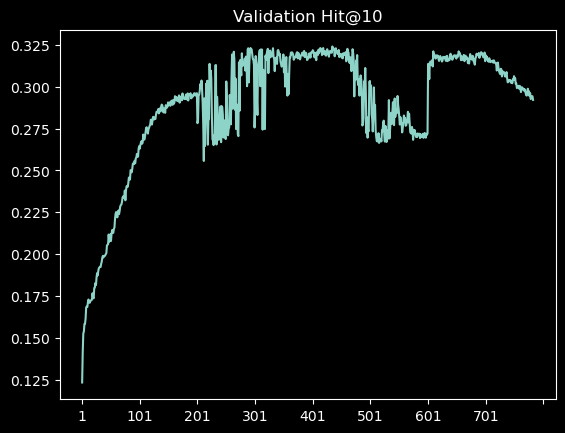

In [6]:
training_metrics["Val Hit@10"].plot(title="Validation Hit@10")

<Axes: title={'center': 'Validation MRR'}>

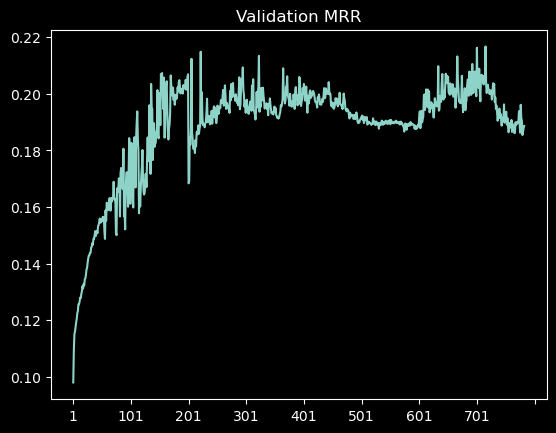

In [7]:
training_metrics["Val MRR"].plot(title="Validation MRR")

In [8]:
0.5 * (np.cos(80 / 200 * np.pi) + 1)

0.6545084971874737